## MACHINE LEARNING PROJECT FOR COMPUTER VISION - CLOUDS ##

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cloud = fetch_ucirepo(id=155) 
  
# data (as pandas dataframes) 
X = cloud.data.features 
y = cloud.data.targets 
  
# metadata 
print(cloud.metadata) 
  
# variable information 
print(cloud.variables) 


{'uci_id': 155, 'name': 'Cloud', 'repository_url': 'https://archive.ics.uci.edu/dataset/155/cloud', 'data_url': 'https://archive.ics.uci.edu/static/public/155/data.csv', 'abstract': 'Little Documentation', 'area': 'Climate and Environment', 'tasks': ['Other'], 'characteristics': ['Multivariate', 'Image'], 'num_instances': 1024, 'num_features': 10, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Mar 08 2024', 'dataset_doi': '10.24432/C5359Z', 'creators': ['Philippe Collard'], 'intro_paper': None, 'additional_info': {'summary': 'The data sets we propose to analyse are constituted of 1024 vectors, each vector includes 10 parameters. You can think of it as a 1024*10 matrix. To produce these vectors, we proceed as follows:\r\n\r\n1. we start with two 512*512 AVHRR images  (1 in the visible, 1 in the IR)\r\n2. each images is divided in super-

Dataset Shape: (2048, 10)

First few rows:
   visible-mean  visible-max  visible-min  mean-distribution  contrast  \
0           3.0        140.0      43.5000             0.0833  862.8417   
1           3.0        135.0      41.9063             0.0790  690.3291   
2           2.0        126.0      21.0586             0.0406  308.3583   
3           4.0        197.0      77.4805             0.0890  874.4709   
4           7.0        193.0      88.8398             0.0884  810.1126   

   entropy  second-angular-momentum  ir-mean  ir-max    ir-min  
0   0.0254                   3.8890    163.0   240.0  213.3555  
1   0.0259                   3.8340    167.0   239.0  213.7188  
2   0.0684                   3.1702    174.0   240.0  227.5859  
3   0.0243                   3.9442    155.0   239.0  197.2773  
4   0.0223                   3.9318    150.0   236.0  186.0195  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2048 entries, 0 to 2047
Data columns (total 10 columns):
 #   Column

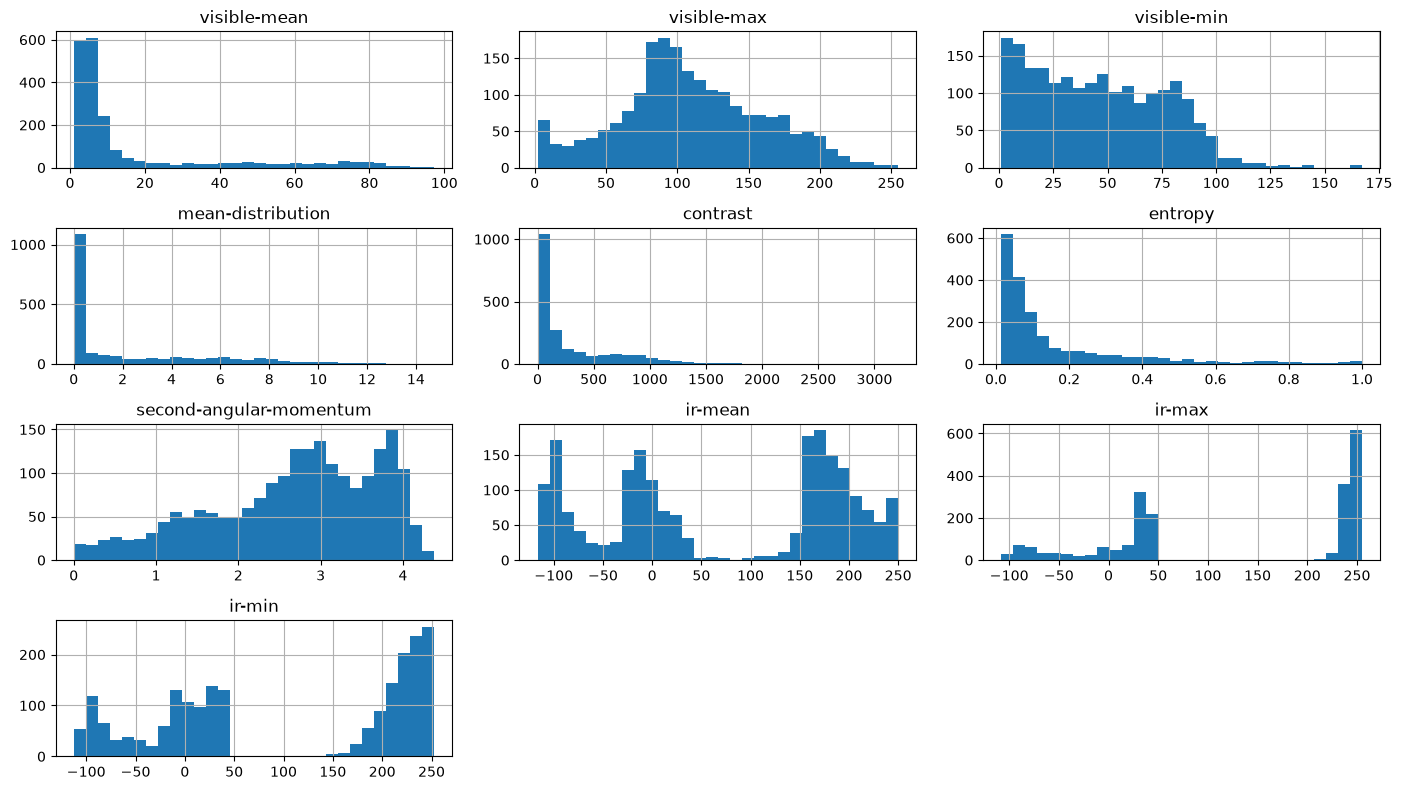

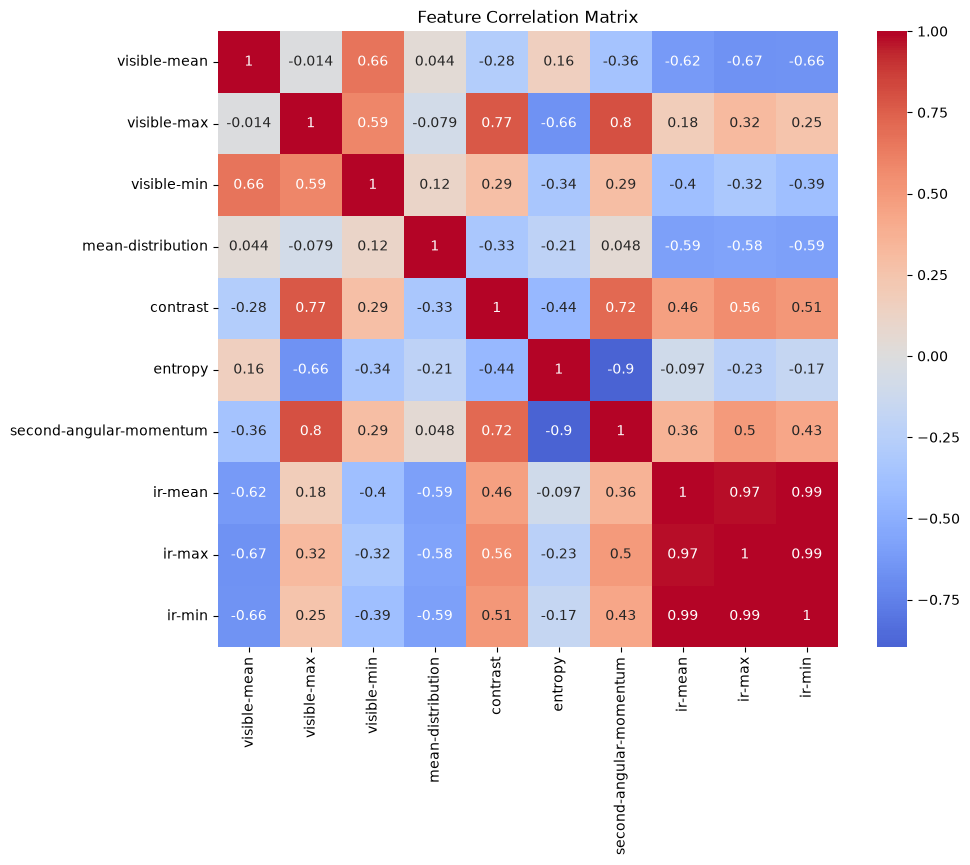

In [2]:
import seaborn as sns

import matplotlib.pyplot as plt

# Display basic information about the dataset
print("Dataset Shape:", X.shape)
print("\nFirst few rows:")
print(X.head())
print("\nDataset Info:")
print(X.info())
print("\nStatistical Summary:")
print(X.describe())

# Check for missing values
print("\nMissing Values:")
print(X.isnull().sum())

# Visualize distributions
X.hist(figsize=(14, 8), bins=30)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

## Computer Vision - Cloud Image Classification (Kaggle) ##

In [3]:
import pathlib
import pandas as pd
import kagglehub

dataset_path = kagglehub.dataset_download("nakendraprasathk/cloud-image-classification-dataset")
data_dir = pathlib.Path(dataset_path) / "data"
train_dir = data_dir / "train"
test_dir = data_dir / "test"

class_names = sorted(p.name for p in train_dir.iterdir() if p.is_dir())
print("Dataset path:", dataset_path)
print("Classes:", class_names)
for c in class_names:
    print(f"  {c}: {len(list((train_dir / c).glob('*.jpg')))} images")
print("Test images:", len(list(test_dir.glob("*.jpg"))))

c:\Users\Mlrivera\OneDrive - CELSIA S.A E.S.P\Escritorio\Optimizacion\Job\CloudsDL\venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: C:\Users\Mlrivera\.cache\kagglehub\datasets\nakendraprasathk\cloud-image-classification-dataset\versions\1
Classes: ['Ac', 'As', 'Cb', 'Cc', 'Ci', 'Cs', 'Ct', 'Cu', 'Ns', 'Sc', 'St']
  Ac: 201 images
  As: 168 images
  Cb: 222 images
  Cc: 248 images
  Ci: 119 images
  Cs: 267 images
  Ct: 180 images
  Cu: 162 images
  Ns: 254 images
  Sc: 320 images
  St: 182 images
Test images: 220


Found 2323 files belonging to 11 classes.
Using 1859 files for training.
Found 2323 files belonging to 11 classes.
Using 464 files for validation.


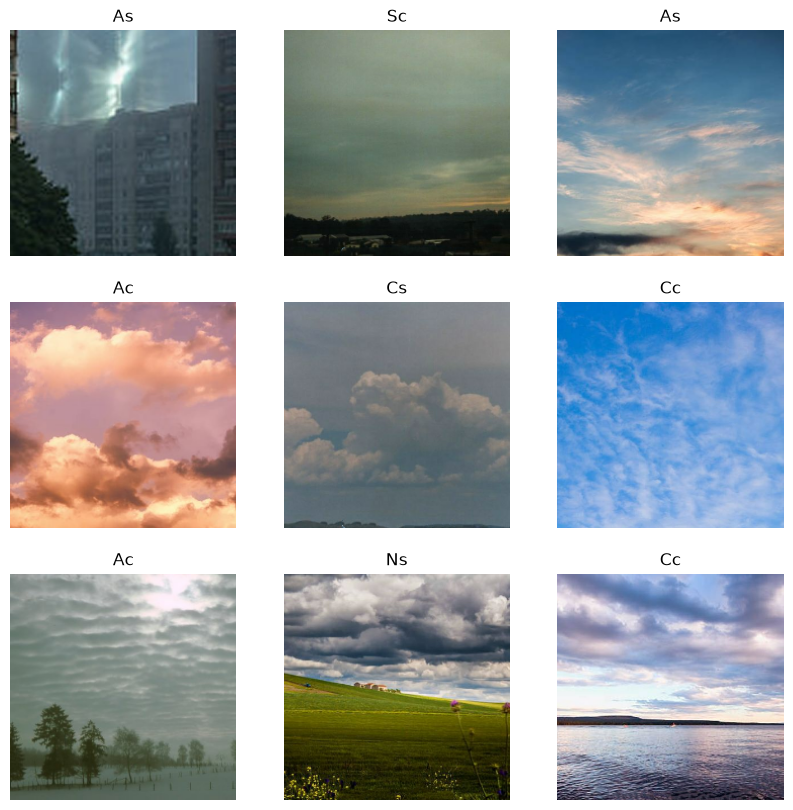

In [4]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=class_names,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=class_names,
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │        14,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,272,075 (8.67 MB)

 Trainable params: 14,091 (55.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/25


c:\Users\Mlrivera\OneDrive - CELSIA S.A E.S.P\Escritorio\Optimizacion\Job\CloudsDL\venv312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


59/59 ━━━━━━━━━━━━━━━━━━━━ 47s 699ms/step - accuracy: 0.2087 - loss: 2.3601 - val_accuracy: 0.3017 - val_loss: 2.0010
Epoch 2/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 40s 684ms/step - accuracy: 0.3523 - loss: 1.9052 - val_accuracy: 0.3384 - val_loss: 1.8425
Epoch 3/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 40s 680ms/step - accuracy: 0.3889 - loss: 1.7901 - val_accuracy: 0.3599 - val_loss: 1.7817
Epoch 4/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 41s 703ms/step - accuracy: 0.4002 - loss: 1.7244 - val_accuracy: 0.3750 - val_loss: 1.7180
Epoch 5/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 46s 786ms/step - accuracy: 0.4438 - loss: 1.6166 - val_accuracy: 0.3815 - val_loss: 1.7088
Epoch 6/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.4529 - loss: 1.5779 - val_accuracy: 0.4159 - val_loss: 1.6947
Epoch 7/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 66s 778ms/step - accuracy: 0.4588 - loss: 1.5729 - val_accuracy: 0.3944 - val_loss: 1.6873
Epoch 8/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.4750 - loss: 1.5187 - val_accuracy: 0.4009 - va

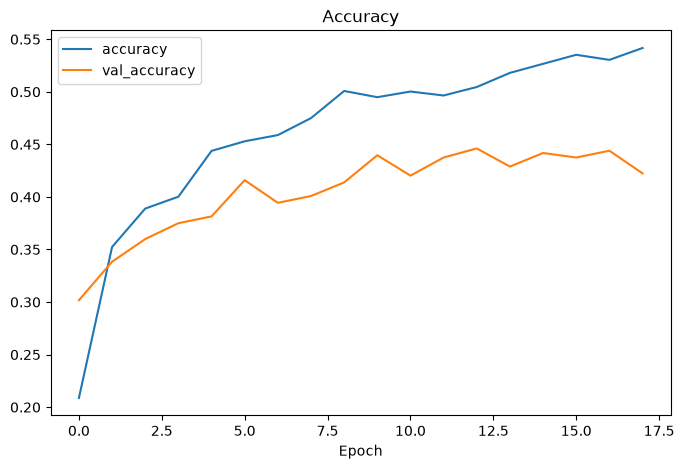

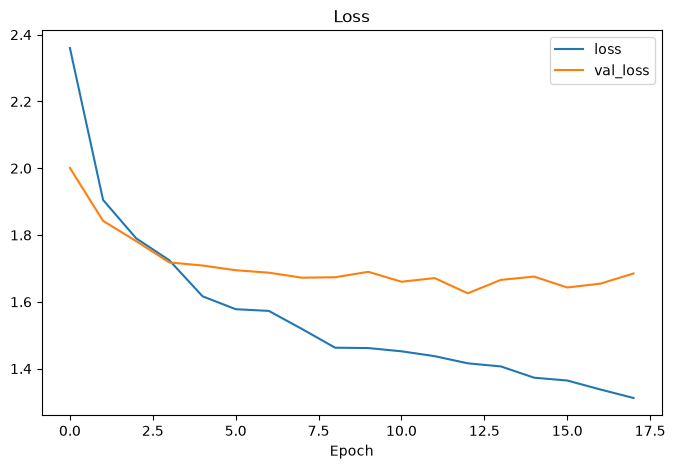

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop],
)

pd.DataFrame(history.history)[["accuracy", "val_accuracy"]].plot(figsize=(8, 5))
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.show()

pd.DataFrame(history.history)[["loss", "val_loss"]].plot(figsize=(8, 5))
plt.title("Loss")
plt.xlabel("Epoch")
plt.show()

              precision    recall  f1-score   support

          Ac       0.36      0.27      0.31        33
          As       0.35      0.29      0.32        24
          Cb       0.44      0.82      0.57        44
          Cc       0.50      0.57      0.53        56
          Ci       0.36      0.19      0.25        21
          Cs       0.35      0.34      0.35        67
          Ct       0.86      0.81      0.83        31
          Cu       0.30      0.24      0.27        29
          Ns       0.46      0.44      0.45        57
          Sc       0.43      0.61      0.51        59
          St       0.43      0.07      0.12        43

    accuracy                           0.45       464
   macro avg       0.44      0.42      0.41       464
weighted avg       0.44      0.45      0.42       464



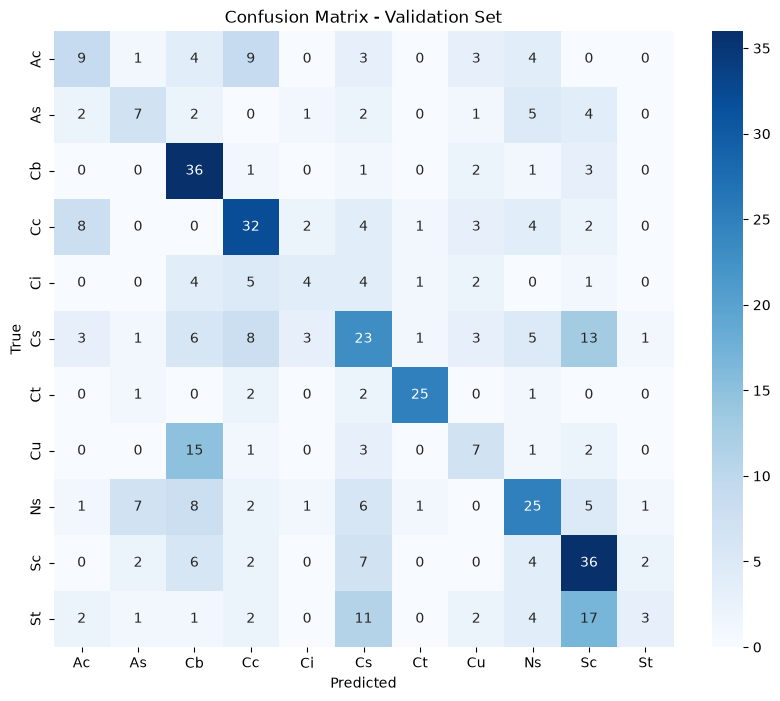

In [7]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Validation Set")
plt.show()

In [8]:
test_files = sorted(test_dir.glob("*.jpg"), key=lambda p: int(p.stem))

def load_test_image(path):
    img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
    return tf.keras.utils.img_to_array(img)

test_images = np.stack([load_test_image(p) for p in test_files])
test_preds = model.predict(test_images, verbose=0)
test_labels = [class_names[i] for i in np.argmax(test_preds, axis=1)]

submission = pd.DataFrame({
    "Index": [int(p.stem) for p in test_files],
    "Class": test_labels,
})
submission.to_csv("submission.csv", index=False)
submission.head()

,Index,Class
0,1,Cb
1,2,Sc
2,3,Cb
3,4,Cb
4,5,Cb
